<a href="https://colab.research.google.com/github/Krishanu2006/Innovat3/blob/main/Copy_of_AIML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

columns = [
    'Age','Gender','Total_Bilirubin',
    'Direct_Bilirubin','Alkphose',
    'Sgpt','Sgot','TP','ALB','A/G_Ratio','Selector'
]

data = pd.read_csv('/content/ILPD.csv',names=columns)

data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkphose,Sgpt,Sgot,TP,ALB,A/G_Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               583 non-null    int64  
 1   Gender            583 non-null    object 
 2   Total_Bilirubin   583 non-null    float64
 3   Direct_Bilirubin  583 non-null    float64
 4   Alkphose          583 non-null    int64  
 5   Sgpt              583 non-null    int64  
 6   Sgot              583 non-null    int64  
 7   TP                583 non-null    float64
 8   ALB               583 non-null    float64
 9   A/G_Ratio         579 non-null    float64
 10  Selector          583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [ ]:
data.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkphose,Sgpt,Sgot,TP,ALB,A/G_Ratio,Selector
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


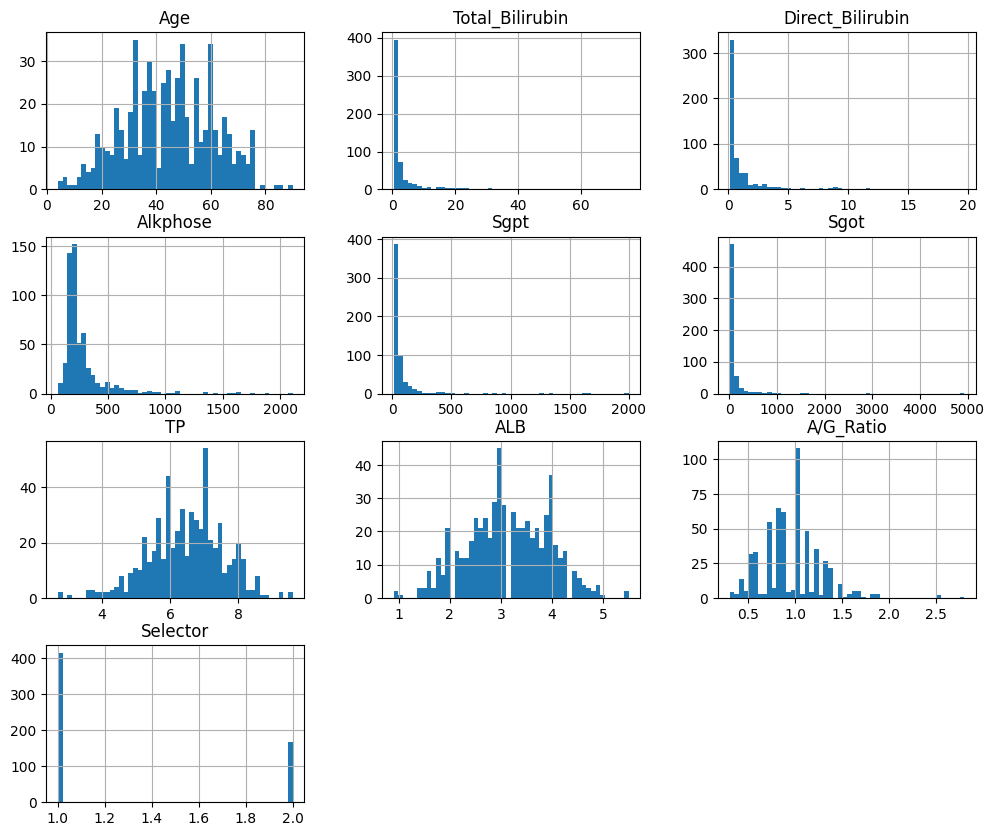

In [ ]:
import matplotlib.pyplot as plt

data.hist(bins=50,figsize=(12,10))
plt.show()


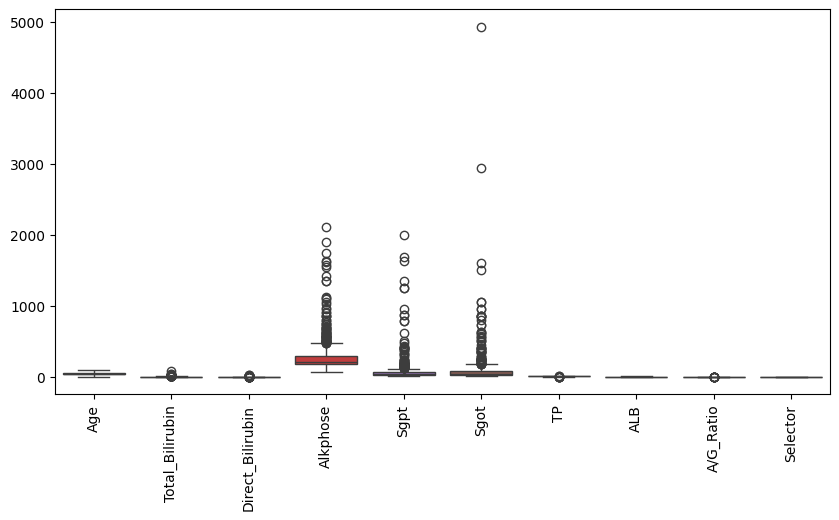

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

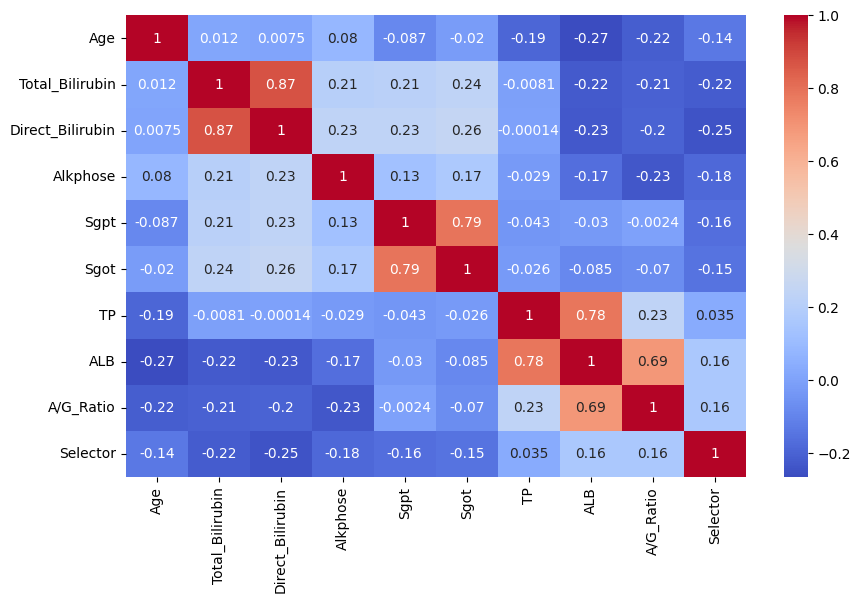

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

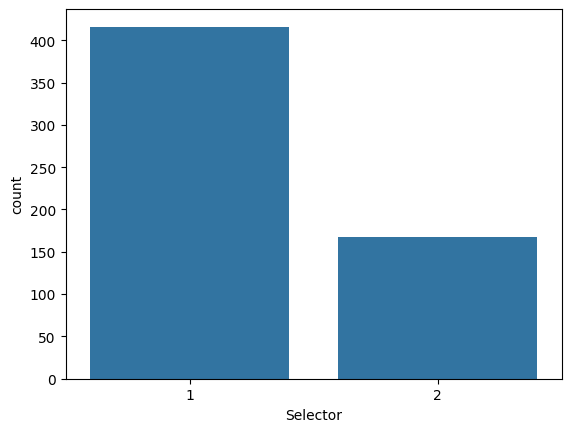

In [ ]:
sns.countplot(x='Selector', data=data)
plt.show()

In [ ]:
data['Gender'] = data['Gender'].map({'Male':1, 'Female':0})

In [ ]:
data['Selector'] = data['Selector'].map({1:1, 2:0})

In [ ]:
from imblearn.over_sampling import SMOTE
X = data.drop('Selector',axis=1)
y = data['Selector']

# Fill missing values in A/G_Ratio with the median before applying SMOTE
X['A/G_Ratio'] = X['A/G_Ratio'].fillna(X['A/G_Ratio'].median())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

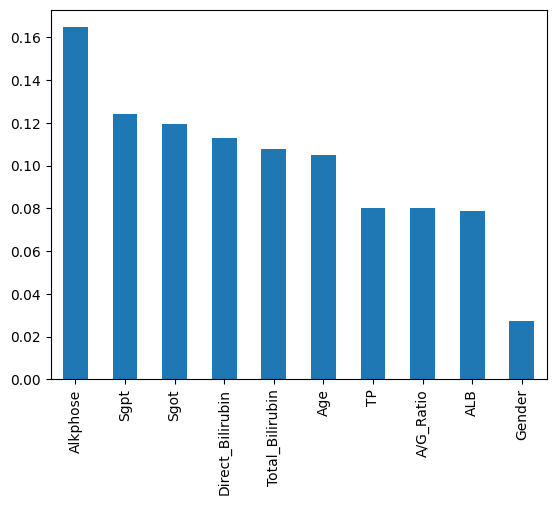

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_resampled, y_resampled)

importances = rf.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "Logistic": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier()
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
print(results_df)

           Model  Accuracy  Precision    Recall        F1
0       Logistic  0.742515   0.728571  0.680000  0.703448
1  Decision Tree  0.820359   0.816901  0.773333  0.794521
2  Random Forest  0.814371   0.782051  0.813333  0.797386
3            SVM  0.736527   0.771930  0.586667  0.666667
4            KNN  0.712575   0.707692  0.613333  0.657143
5        XGBoost  0.814371   0.761905  0.853333  0.805031


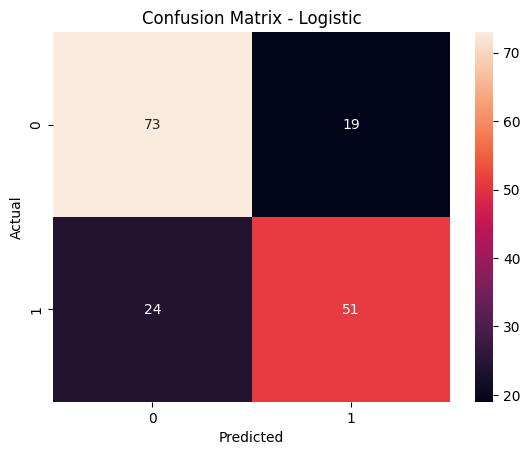

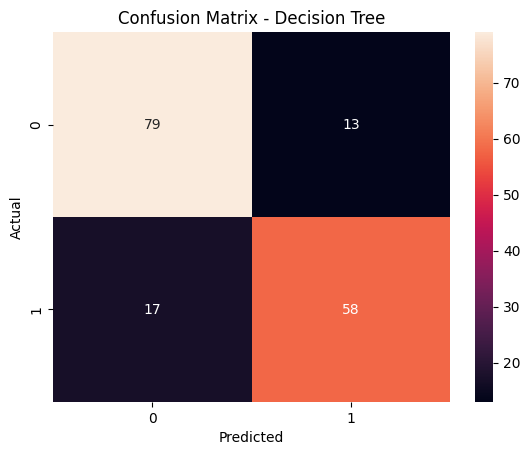

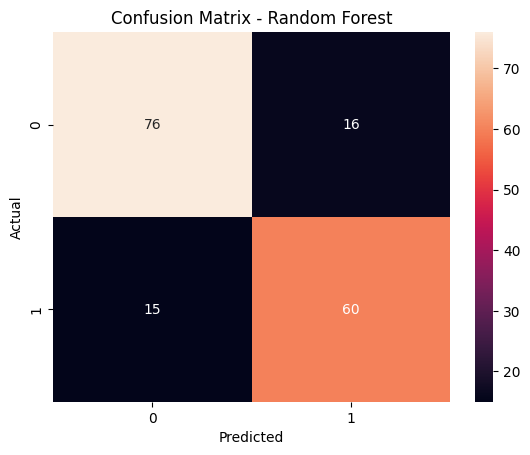

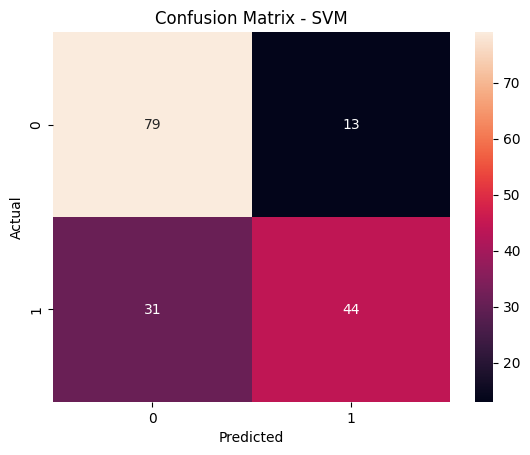

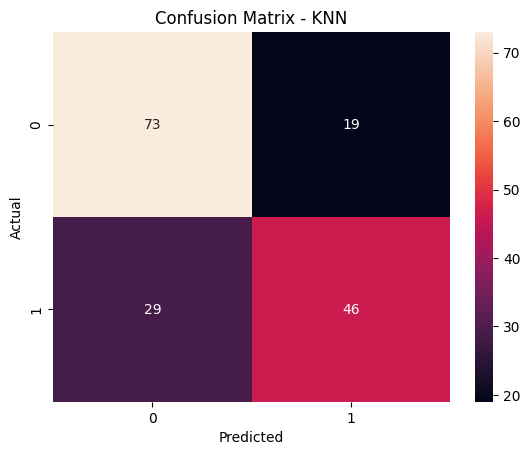

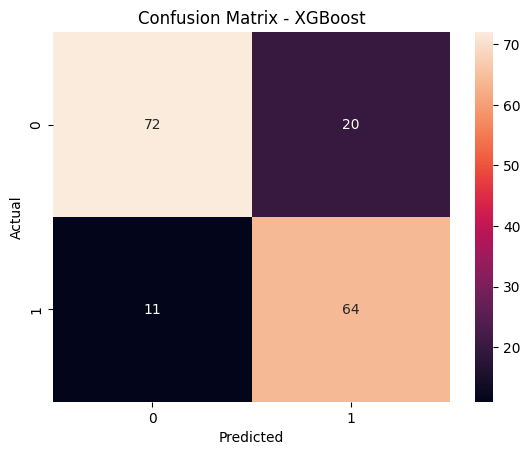

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

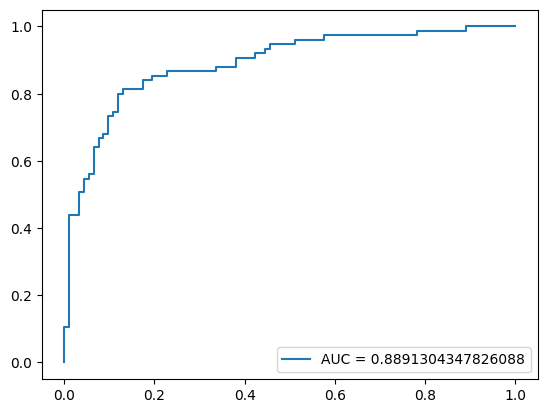

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc}")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(RandomForestClassifier(), X_scaled, y_resampled, cv=5)

print(scores.mean())

0.760911911117524


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [None,10,20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 100}
